In [1]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from category_encoders import WOEEncoder

df = pd.read_csv("UCI_Credit_Card.csv")
df = df.set_index('ID')
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
print(len(df.index))

30000


In [3]:
class_imbalance = (df["default.payment.next.month"] == 1).mean().item()
class_imbalance

0.2212

In [4]:
df["MARRIAGE"].unique()

array([1, 2, 3, 0], dtype=int64)

In [5]:
df.loc[df['MARRIAGE'] == 0, "MARRIAGE"] = 3
df["MARRIAGE"].unique()

array([1, 2, 3], dtype=int64)

In [6]:
df["EDUCATION"].unique()

array([2, 1, 3, 5, 4, 6, 0], dtype=int64)

In [7]:
df.loc[df['EDUCATION'].isin([0, 5, 6]), "EDUCATION"] = 4
df["EDUCATION"].unique()

array([2, 1, 3, 4], dtype=int64)

In [8]:
X_raw = df.drop(columns = ["default.payment.next.month"])
y_raw = df["default.payment.next.month"]

from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    stratify=y_raw,
    random_state=42
)


X_train_raw = X_raw.loc[train_idx]
X_test_raw = X_raw.loc[test_idx]

y_train = y_raw.loc[train_idx]
y_test = y_raw.loc[test_idx]

X = X_train_raw.copy() 
y = y_train.copy() # to work with

In [9]:
lr_model = sm.Logit(y, sm.add_constant(X)).fit()
lr_model.summary()

Optimization terminated successfully.
         Current function value: 0.463221
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                               Logit Regression Results                               
======================================================================================
Dep. Variable:     default.payment.next.month   No. Observations:                24000
Model:                                  Logit   Df Residuals:                    23976
Method:                                   MLE   Df Model:                           23
Date:                        Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1234
Time:                                21:25:12   Log-Likelihood:                -11117.
converged:                               True   LL-Null:                       -12682.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6136      0.133     -4.605      0.000      -0.875      -0.352
LIMIT_BAL  -1.033e-06   1.78e-07     -5.813      0.000   -1.38e-06   -6.85e-07
SEX           -0.1159      0.034     -3.374      0.001      -0.183      -0.049
EDUCATION     -0.1226      0.025     -4.971      0.000      -0.171      -0.074
MARRIAGE      -0.1591      0.036     -4.475      0.000      -0.229      -0.089
AGE            0.0076      0.002      3.792      0.000       0.004       0.012
PAY_0          0.5882      0.020     29.678      0.000       0.549       0.627
PAY_2          0.0777      0.022      3.457      0.001       0.034       0.122
PAY_3          0.0813      0.025      3.231      0.001       0.032       0.131
PAY_4          0.0535      0.028      1.925      0.054      -0.001       0.108
PAY_5         -0.0014      0.030     -0.047      0.962      -0.060       0.058
PAY_6          0.0151      0.025      0.611      0.541      -0.033       0.063
BILL_AMT1  -4.373e-06   1.21e-06     -3.609      0.000   -6.75e-06      -2e-06
BILL_AMT2   1.448e-06   1.66e-06      0.871      0.384   -1.81e-06    4.71e-06
BILL_AMT3    4.53e-07   1.54e-06      0.294      0.769   -2.57e-06    3.47e-06
BILL_AMT4   7.947e-07    1.5e-06      0.529      0.597   -2.15e-06    3.74e-06
BILL_AMT5   4.724e-07   1.63e-06      0.289      0.773   -2.73e-06    3.68e-06
BILL_AMT6  -7.592e-08    1.3e-06     -0.058      0.954   -2.63e-06    2.48e-06
PAY_AMT1   -1.236e-05   2.53e-06     -4.883      0.000   -1.73e-05    -7.4e-06
PAY_AMT2   -8.841e-06    2.3e-06     -3.842      0.000   -1.34e-05   -4.33e-06
PAY_AMT3    -1.96e-06   1.87e-06     -1.050      0.294   -5.62e-06     1.7e-06
PAY_AMT4   -2.505e-06   1.92e-06     -1.301      0.193   -6.28e-06    1.27e-06
PAY_AMT5   -1.481e-06    1.9e-06     -0.781      0.435    -5.2e-06    2.23e-06
PAY_AMT6   -1.639e-06   1.43e-06     -1.149      0.251   -4.43e-06    1.16e-06
==============================================================================
"""

In [10]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Feature,VIF
0,LIMIT_BAL,4.051262
1,SEX,9.172770
2,EDUCATION,7.395163
3,MARRIAGE,6.388384
4,AGE,11.163508
5,PAY_0,1.893689
6,PAY_2,3.188720
7,PAY_3,3.696694
8,PAY_4,4.382317
9,PAY_5,4.936839


In [11]:
X['AVG_BILL_AMT'] = X[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1)
X = X.drop(columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'])

X['AVG_PAY_AMT3_6'] = X[['PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)
X = X.drop(columns=['PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'])

In [12]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Feature,VIF
0,LIMIT_BAL,4.030533
1,SEX,9.154521
2,EDUCATION,7.375191
3,MARRIAGE,6.384618
4,AGE,11.161662
5,PAY_0,1.892340
6,PAY_2,3.162206
7,PAY_3,3.678911
8,PAY_4,4.318559
9,PAY_5,4.803588


In [13]:
lr_model = sm.Logit(y, sm.add_constant(X)).fit()
lr_model.summary()

Optimization terminated successfully.
         Current function value: 0.463683
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                               Logit Regression Results                               
======================================================================================
Dep. Variable:     default.payment.next.month   No. Observations:                24000
Model:                                  Logit   Df Residuals:                    23984
Method:                                   MLE   Df Model:                           15
Date:                        Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1225
Time:                                21:25:14   Log-Likelihood:                -11128.
converged:                               True   LL-Null:                       -12682.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.6209      0.133     -4.665      0.000      -0.882      -0.360
LIMIT_BAL      -1.069e-06   1.77e-07     -6.035      0.000   -1.42e-06   -7.22e-07
SEX               -0.1103      0.034     -3.215      0.001      -0.178      -0.043
EDUCATION         -0.1279      0.025     -5.196      0.000      -0.176      -0.080
MARRIAGE          -0.1603      0.036     -4.513      0.000      -0.230      -0.091
AGE                0.0076      0.002      3.820      0.000       0.004       0.012
PAY_0              0.5924      0.020     29.822      0.000       0.553       0.631
PAY_2              0.0674      0.022      3.005      0.003       0.023       0.111
PAY_3              0.0858      0.025      3.413      0.001       0.037       0.135
PAY_4              0.0547      0.028      1.985      0.047       0.001       0.109
PAY_5              0.0069      0.030      0.232      0.816      -0.051       0.065
PAY_6              0.0218      0.024      0.904      0.366      -0.025       0.069
PAY_AMT1       -1.034e-05   2.33e-06     -4.434      0.000   -1.49e-05   -5.77e-06
PAY_AMT2       -7.802e-06   2.06e-06     -3.780      0.000   -1.18e-05   -3.76e-06
AVG_BILL_AMT   -1.742e-06   3.64e-07     -4.792      0.000   -2.45e-06   -1.03e-06
AVG_PAY_AMT3_6 -7.799e-06   2.84e-06     -2.743      0.006   -1.34e-05   -2.23e-06
==================================================================================
"""

In [14]:
age_bins = [0, 25, 35, 45, 55, 100]
age_labels = ['Young', 'Young_Professional', 'Mid_Career', 'Established', 'Senior']
X['AGE_BUCKET'] = pd.cut(X['AGE'], bins = age_bins, labels = age_labels)
X = X.drop(columns=['AGE'])

import warnings
warnings.filterwarnings('ignore')
X_iv_check = X.copy()


continuous_cols = ['LIMIT_BAL', 'AVG_BILL_AMT', 'AVG_PAY_AMT3_6', 'PAY_AMT1', 'PAY_AMT2'] 


for col in continuous_cols:
    X_iv_check[col + '_BINNED'] = pd.qcut(X_iv_check[col], q = 5, duplicates='drop').astype(str)


def calculate_iv(df, feature, target):
    data = pd.DataFrame({'Variable': df[feature], 'Target': target})
    
    grouped = data.groupby('Variable', as_index=False).agg(
        Good = ('Target', lambda x: (x == 0).sum()),
        Bad = ('Target', lambda x: (x == 1).sum())
    )
    
    epsilon = 1e-6
    grouped['Good_Dist'] = np.maximum(grouped['Good'] / grouped['Good'].sum(), epsilon)
    grouped['Bad_Dist'] = np.maximum(grouped['Bad'] / grouped['Bad'].sum(), epsilon)
    
    grouped['WoE'] = np.log(grouped['Good_Dist'] / grouped['Bad_Dist'])
    grouped['IV'] = (grouped['Good_Dist'] - grouped['Bad_Dist']) * grouped['WoE']
    
    return grouped['IV'].sum()

valid_iv_cols = [
    'SEX', 'EDUCATION', 'MARRIAGE', 'AGE_BUCKET',
    'LIMIT_BAL_BINNED', 'AVG_BILL_AMT_BINNED', 'AVG_PAY_AMT3_6_BINNED',
    'PAY_AMT1_BINNED', 'PAY_AMT2_BINNED', 
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
]

iv_results = {}
for col in valid_iv_cols:
    if col in X_iv_check.columns:  
        iv_results[col] = calculate_iv(X_iv_check, col, y)

iv_df = pd.DataFrame(list(iv_results.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by = 'IV', ascending = False).reset_index(drop=True)

print(iv_df)

                  Feature        IV
0                   PAY_0  0.889401
1                   PAY_2  0.552321
2                   PAY_3  0.420597
3                   PAY_4  0.369785
4                   PAY_5  0.336735
5                   PAY_6  0.294036
6        LIMIT_BAL_BINNED  0.171363
7         PAY_AMT1_BINNED  0.159910
8         PAY_AMT2_BINNED  0.139435
9   AVG_PAY_AMT3_6_BINNED  0.132288
10              EDUCATION  0.036380
11             AGE_BUCKET  0.022347
12    AVG_BILL_AMT_BINNED  0.016526
13                    SEX  0.011049
14               MARRIAGE  0.004702


In [15]:
age_encoder = WOEEncoder(cols=['AGE_BUCKET'])
X = age_encoder.fit_transform(X, y)

pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'AVG_PAY_AMT3_6', 'LIMIT_BAL']

saved_bins = {}

for col in pay_amt_cols:
    if col in X.columns:

        X[col + '_BINNED'], bins = pd.qcut(X[col], q = 5, retbins = True, duplicates = 'drop')
        X[col + '_BINNED'] = X[col + '_BINNED'].astype(str)
        
        bins[0] = -np.inf
        bins[-1] = np.inf
        
        saved_bins[col] = bins

X = X.drop(columns = pay_amt_cols)

encoder = WOEEncoder(cols = ["EDUCATION", "PAY_0", "PAY_2", "PAY_3", "PAY_4",
                                  "PAY_5", "PAY_6", 'PAY_AMT1_BINNED', 'PAY_AMT2_BINNED', 'AVG_PAY_AMT3_6_BINNED', 
                             'LIMIT_BAL_BINNED'])
X = encoder.fit_transform(X, y)

X = X.drop(columns = ['MARRIAGE', 'SEX', 'AVG_BILL_AMT'])

In [16]:
lr_model3 = sm.Logit(y, sm.add_constant(X)).fit()
lr_model3.summary()

Optimization terminated successfully.
         Current function value: 0.435167
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                               Logit Regression Results                               
======================================================================================
Dep. Variable:     default.payment.next.month   No. Observations:                24000
Model:                                  Logit   Df Residuals:                    23987
Method:                                   MLE   Df Model:                           12
Date:                        Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1765
Time:                                21:25:15   Log-Likelihood:                -10444.
converged:                               True   LL-Null:                       -12682.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.2462      0.018    -70.523      0.000      -1.281      -1.212
EDUCATION                 0.3823      0.096      4.000      0.000       0.195       0.570
PAY_0                     0.7669      0.022     34.271      0.000       0.723       0.811
PAY_2                     0.0100      0.037      0.270      0.787      -0.063       0.082
PAY_3                     0.1765      0.045      3.882      0.000       0.087       0.266
PAY_4                     0.1934      0.045      4.257      0.000       0.104       0.282
PAY_5                     0.1307      0.047      2.762      0.006       0.038       0.223
PAY_6                     0.2101      0.044      4.775      0.000       0.124       0.296
AGE_BUCKET                0.3941      0.119      3.300      0.001       0.160       0.628
PAY_AMT1_BINNED           0.2686      0.058      4.642      0.000       0.155       0.382
PAY_AMT2_BINNED           0.2395      0.063      3.780      0.000       0.115       0.364
AVG_PAY_AMT3_6_BINNED     0.2527      0.062      4.060      0.000       0.131       0.375
LIMIT_BAL_BINNED          0.3009      0.049      6.194      0.000       0.206       0.396
=========================================================================================
"""

In [17]:
X = X.drop(columns = ['PAY_2'])

In [18]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Feature,VIF
0,EDUCATION,1.046388
1,PAY_0,1.456516
2,PAY_3,2.275071
3,PAY_4,2.579362
4,PAY_5,2.588095
5,PAY_6,1.944470
6,AGE_BUCKET,1.075427
7,PAY_AMT1_BINNED,1.569720
8,PAY_AMT2_BINNED,1.828104
9,AVG_PAY_AMT3_6_BINNED,1.724531


In [19]:
X_train_m3 = X.copy()

X_test_m3 = X_test_raw.copy()

X_test_m3['AGE_BUCKET'] = pd.cut(X_test_m3['AGE'], bins = age_bins, labels = age_labels)
X_test_m3 = X_test_m3.drop(columns=['AGE'])
X_test_m3['AVG_BILL_AMT'] = X_test_m3[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1)
X_test_m3 = X_test_m3.drop(columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'])
X_test_m3['AVG_PAY_AMT3_6'] = X_test_m3[['PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)
X_test_m3 = X_test_m3.drop(columns=['PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'])

X_test_m3 = age_encoder.transform(X_test_m3)

pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'AVG_PAY_AMT3_6', 'LIMIT_BAL']

for col in pay_amt_cols:
    if col in X_test_m3.columns:
        X_test_m3[col + '_BINNED'] = pd.cut(X_test_m3[col], bins = saved_bins[col]).astype(str)

X_test_m3 = X_test_m3.drop(columns = pay_amt_cols)

X_test_m3 = encoder.transform(X_test_m3)

X_test_m3 = X_test_m3.drop(columns = ['MARRIAGE', 'SEX', 'AVG_BILL_AMT', 'PAY_2'])

In [20]:
import warnings

warnings.filterwarnings('ignore', message=".*line search algorithm did not converge.*")


from sklearn.linear_model import LogisticRegression

lr_raw = LogisticRegression(
    solver='newton-cg',
    max_iter=10000
)

lr_raw.fit(X_train_raw, y_train)

raw_probs = lr_raw.predict_proba(X_test_raw)[:, 1]
raw_pred = (raw_probs >= 0.35).astype(int)


lr_m3 = LogisticRegression(
    solver='newton-cg',
    max_iter=10000
)

lr_m3.fit(X_train_m3, y_train)

m3_probs = lr_m3.predict_proba(X_test_m3)[:, 1]
m3_pred = (m3_probs >= 0.35).astype(int)



from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_nn = scaler.fit_transform(X_train_raw)
X_test_nn = scaler.transform(X_test_raw)



from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_nn, y_train)


mlp_probs = mlp.predict_proba(X_test_nn)[:, 1]
mlp_pred = (mlp_probs >= 0.35).astype(int)



from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }


results = pd.DataFrame([

    evaluate_model(
        "Raw Logistic Regression",
        y_test,
        raw_pred,
        raw_probs
    ),

    evaluate_model(
        "Final Logistic Regression",
        y_test,
        m3_pred,
        m3_probs
    ),

    evaluate_model(
        "Neural Network",
        y_test,
        mlp_pred,
        mlp_probs
    )

])

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Raw Logistic Regression,0.808833,0.596983,0.417483,0.491353,0.707947
1,Final Logistic Regression,0.816500,0.631702,0.408440,0.496110,0.744216
2,Neural Network,0.795000,0.540518,0.487566,0.512678,0.760662


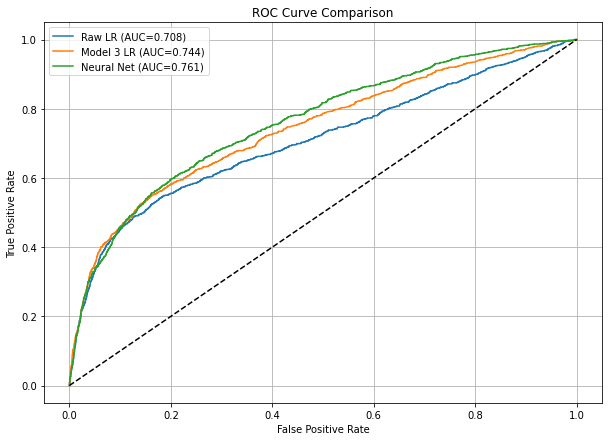

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_raw, tpr_raw, _ = roc_curve(y_test, raw_probs)
fpr_m3, tpr_m3, _ = roc_curve(y_test, m3_probs)
fpr_nn, tpr_nn, _ = roc_curve(y_test, mlp_probs)

plt.figure(figsize = (10,7))

plt.plot(
    fpr_raw,
    tpr_raw,
    label=f"Raw LR (AUC={roc_auc_score(y_test, raw_probs):.3f})"
)

plt.plot(
    fpr_m3,
    tpr_m3,
    label=f"Model 3 LR (AUC={roc_auc_score(y_test, m3_probs):.3f})"
)

plt.plot(
    fpr_nn,
    tpr_nn,
    label=f"Neural Net (AUC={roc_auc_score(y_test, mlp_probs):.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid()

plt.show()